<a href="https://colab.research.google.com/github/JoaoVitorCoelhoG/Aprendizado-Profundo/blob/main/cm204_lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instituto Tecnológico de Aeronáutica – ITA**

**Aprendizado Profundo - CM-204**

**Professores:**

Marcos Ricardo Omena de Albuquerque Maximo

André Oliveira Françani


# Laboratório 4 – Segmentação Semântica com U-Net

**Observação: Não** exclua células, pois isto pode gerar problemas para o autocorretor.

# 1. Introdução

Neste laboratório, seu objetivo é implementar uma rede neural convolucional da arquitetura U-Net para realizar uma tarefa de segmentação semântica, que é basicamente uma classificação feita para cada pixel da imagem. A segmentação das imagens será feita no contexto de imagens aéreas de Dubai da base de dados [Semantic Segmentation of Aerial Imagery](https://www.kaggle.com/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery).

# 2. Descrição do Problema

O problema consiste em segmentar imagens aéreas utilizando uma rede neural convolucional do tipo U-Net. Essa arquitetura é muito popular, sendo originalmente desenvolvida para segmentar células em imagens médicas. Entretanto, ela tem sido usada com muito sucesso em diversas áreas de processamento de imagem.

O seu nome está relacionado com o formato de sua arquitetura em "U". O lado esquerdo da arquitetura, chamado de *encoder* ou caminho de contração, é composto por camadas de pooling que reduzem a dimensão das features. Em seguida, a arquitetura conduz as *features* para o lado direito do "U", chamado de *decoder* ou caminho de expansão. Esse caminho é composto por camadas de *up-sampling*, conectadas com as camadas do *encoder* para preservar as informações perdidas durante o *pooling*. A Figura 1 ilustra a arquitetura U-Net, retirada do [artigo original](https://arxiv.org/pdf/1505.04597.pdf%EF%BC%89). Na Figura, os números em cima dos blocos em azul claro representam o número de filtros/kernels de cada camada.

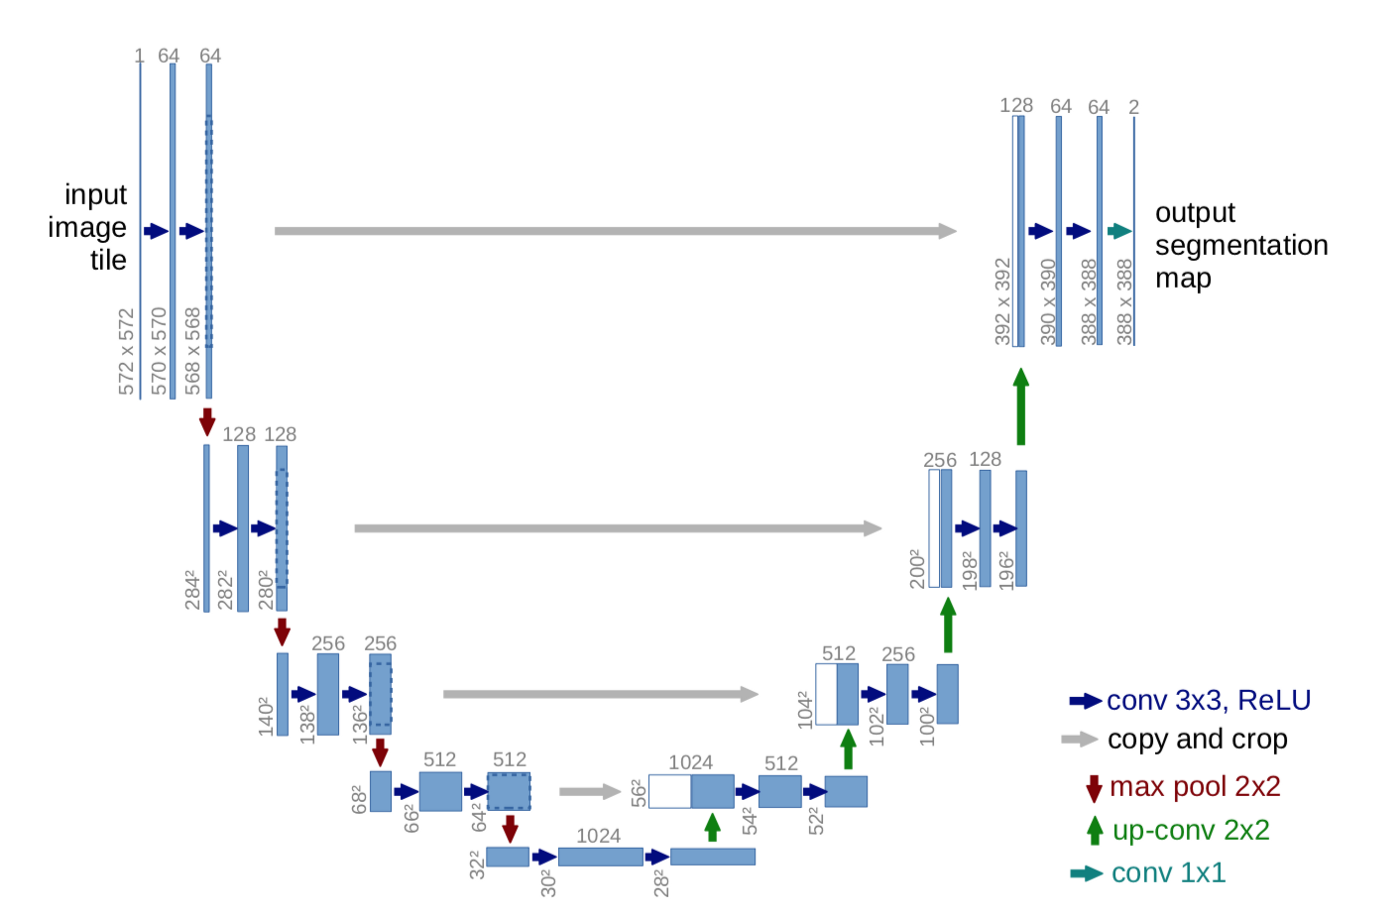

**Figura 1**: arquitetura [U-Net](https://arxiv.org/pdf/1505.04597.pdf%EF%BC%89).



No nosso contexto de imagens aéreas, vamos segmentar as imagens em 6 classes:
- Construção
- Terreno (área não pavimentada)
- Estrada
- Vegetação
- Água
- Sem rótulo

Para a implementação da U-Net, você utilizará o *framework* PyTorch, já utilizado em laboratórios anteriores.

# 3. Código Base

O código fornecido já lê a base de dados e faz todo o pré-processamento necessário para treinar a rede neural. Além disso, a rede neural a ser utilizada já foi treinada anteriormente, pois mesmo para uma base de dados pequena o treinamento pode durar algumas horas usando GPU. Assim, seu objetivo é implementar a U-Net na Seção 4.2 e já carregar os pesos pré-treinados para realizar a segmentação na base de teste.

# 4. Segmentação Semântica de Imagens Aéreas

Comece rodando a célula abaixo para fazer o *download* da base de dados e dos pesos pré-treinados da U-Net.

In [ ]:
import zipfile
import os

# Download data (MUST RUN)
!gdown "1HYckGewMjb29XB4lUlw1miyC6PWHdo9Z&confirm=t"
!gdown "1XpDeIc1yYCpHZ32E9yN5WIeGK9ZKL3Du&confirm=t"

with zipfile.ZipFile("data.zip","r") as zip_ref:
  zip_ref.extractall() # extracts in current directory

os.remove("data.zip")

A base de dados original contém imagens com diferentes tamanhos. Para evitar o *resize* em problemas de segmentação semântica (o que pode prejudicar a qualidade das anotações das classes) nós já dividimos as imagens maiores em imagens de tamanho 256 x 256 para diminuir o processamento da rede e facilitar no treinamento do modelo.


## 4.1. Leitura dos Dados

As imagens anotadas com as classes de cada píxel estão com seus valores em RGB ao invés do valores de sua classe (0, 1, 2, 3, 4, ...). Assim, o primeiro passo é decodificar as cores das anotações em um número inteiro que represente sua classe. Por exemplo, vamos adotar a seguinte codificação:

| Classe | Cor (HEX) | Rótulo (label) |
|:-------|:----------|:--------------:|
| Building | 3C1098 | 0 |
| Land | 8429F6 | 1 |
| Road | 6EC1E4 | 2 |
| Vegetation | FEDD3A | 3 |
| Water | E2A929 | 4 |
| Unlabeled | 9B9B9B | 5 |

Note que as cores foram fornecidas em Hexadecimal. Portanto, precisamos converter em valores RGB para facilitar nosso processamento de imagem. A função `hex_to_rgb()` auxilia na conversão de hexadecimal para valores em RGB, e a função `rgb_to_label()` converte a imagem colorida (com as anotações) em uma imagem cujos valores dos pixels são os valores dos rótulos a que eles pertencem. Não é necessário implementar nada aqui, basta rodar a célula abaixo.

In [ ]:
import numpy as np

classes_dict = {
    "Building": {"color": "3C1098",
                 "label": 0},
    "Land": {"color": "8429F6",
             "label": 1},
    "Road": {"color": "6EC1E4",
             "label": 2},
    "Vegetation": {"color": "FEDD3A",
             "label": 3},
    "Water": {"color": "E2A929",
             "label": 4},
    "Unlabeled": {"color": "9B9B9B",
             "label": 5},
}

def hex_to_rgb(hex):
    return np.array(tuple(int(hex[i:i+2], 16) for i in (0, 2, 4)))

def recolor_labels(img, classes_dict):
    new_img = np.zeros(img.shape + (3,), dtype=np.uint8)
    for cls in list(classes_dict.keys()):
        rgb_color = hex_to_rgb(classes_dict[cls]["color"])
        label = classes_dict[cls]["label"]
        new_img[img == label] = rgb_color
    return new_img

# Make results folder to save images
if not os.path.exists('results'):
  os.makedirs('results')

Uma vez com os dados baixados e com as funções auxiliares, podemos agora ler nossa base de dados. As imagens de entrada, se lidas naturalmente, possuem pixels com valores de 0 a 255. Entretanto, para usar como entrada na rede neural, precisamos normalizar esses valores preferencialmente entre 0 e 1 para facilitar no aprendizado da rede. Esse pré-processamento está sendo feito com o `T.ToTensor()`.

Para permitir seguir um protocolo de treinamento adequado, dividimos o conjunto de dados entre treinamento, validação e teste. O conjunto de validação é usado para *early stopping*, enquanto o de teste é reservado para uma avaliação final da rede treinada.

Como treinar a U-Net demora demais em CPU, neste laboratório, o treinamento é opcional (veja o final do *notebook*). Você implementará a arquitetura da U-Net e avaliará seu desempenho a partir de pesos que já foram treinados previamente pelo professor usando GPU.

In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

def rgb_to_label_pil(pil_mask, classes_dict):
    mask = np.array(pil_mask)
    label_mask = np.zeros(mask.shape[:2], dtype=np.int64)

    for cls, properties in classes_dict.items():
        rgb_color = hex_to_rgb(properties["color"])
        label = properties["label"]
        matches = np.all(mask == rgb_color, axis=-1)
        label_mask[matches] = label

    return torch.from_numpy(label_mask).long()

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_transform=None, mask_transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))

        self.image_transform = image_transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        # print(image_path)
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")
        mask = rgb_to_label_pil(mask, classes_dict)

        if self.image_transform:
            image = self.image_transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)

        return image, mask

In [ ]:
image_transform = T.Compose([
    T.ToTensor(),
])

# Nothing to do to the mask, since it is already a tensor of labels
mask_transform = T.Compose([

])

In [ ]:
dataset = SegmentationDataset(
    image_dir=os.path.join("data", "images"),
    mask_dir=os.path.join("data", "masks"),
    image_transform=image_transform,
    mask_transform=mask_transform
)

In [ ]:
from torch.utils.data import DataLoader, random_split

torch.manual_seed(42)  # for reproducibility

val_size = int(0.15 * len(dataset))
test_size = int(0.15 * len(dataset))
train_size = len(dataset) - val_size - test_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Using num_workers=0 for compability across different platforms. The code may freezes if num_workers > 0 on some platforms.
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

Verifique as dimensões da imagem e da máscara de segmentação já transformadas para tensores do PyTorch.

In [ ]:
images, masks = next(iter(train_loader))

print(images.shape)  # [B, 3, H, W]
print(masks.shape)   # [B, H, W]

Vamos visualizar algumas imagens para garantir que tudo está correto até aqui.

In [ ]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

images, masks = next(iter(val_loader))
images = images.to(device)
masks = masks.to(device)

# Visualize a few images
plt.figure(figsize=(12,6))
for i in range(len(images)):
    img = images[i]
    mask = masks[i]
    img = T.ToPILImage()(img.cpu())
    mask = mask.cpu().numpy()
    plt.subplot(2, 4, 2 * i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.subplot(2, 4, 2* i + 2)
    plt.imshow(recolor_labels(mask, classes_dict), vmin=0, vmax=5)
    plt.axis("off")
    cbar = plt.colorbar()
    cbar.set_ticks([i for i in range(6)]), cbar.set_ticklabels(list(classes_dict.keys()))
    plt.tight_layout()

# 4.2. Implementação da U-Net

Neste laboratório, você precisa apenas modificar as camadas da rede no construtor da classe `UNet` de acordo com a arquitetura da UNet da Figura 1.

Abaixo seguem algumas dicas para implementar a arquitetura UNet corretamente:

- A primeira camada convolucional da U-Net possui 64 canais (*num_filters)*;
- Após as camadas de *Pooling*, dobra-se o número de canais/filtros na camada convolucional seguinte;
- Na parte central da arquitetura, as camadas convolucionais possuem 1024 canais/filtros;
- No *decoder*, o número de canais é reduzido pela metade após as camadas *ConvTranspose2d*;
- As camadas que estão sendo concatenadas em "torch.cat" devem possuir o mesmo número de filtros/canais.
- Você precisa apenas se preocupar em corrigir as linhas de código que estão comentadas, especificamente nos pontos onde há ?.

In [ ]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    """
    Helper module for UNet that performs two consecutive convolutional layers with ReLU activation and dropout.
    """
    def __init__(self, in_channels: int, out_channels):
        """
        Initialize DoubleConv module.
        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
        """
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.1),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through DoubleConv.
        Args:
            x (torch.Tensor): Input tensor of shape [B, in_channels, H, W].
        Returns:
            torch.Tensor: Output tensor of shape [B, out_channels, H, W].
        """
        return self.double_conv(x)


class UNet(nn.Module):
    """
    UNet architecture for image segmentation.
    """
    def __init__(self, in_channels: int, n_classes: int):
        """
        Initialize UNet model.
        Args:
            in_channels (int): Number of input channels (e.g., 3 for RGB).
            n_classes (int): Number of output classes for segmentation.
        """
        super().__init__()

        # Encoder
        self.conv1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # self.conv2 = DoubleConv(?, ?)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # self.conv3 = DoubleConv(?, ?)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # self.conv4 = DoubleConv(?, ?)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Middle
        self.conv5 = DoubleConv(512, 1024)

        # Decoder
        self.upconv6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        # self.conv6 = DoubleConv(?, ?)

        # self.upconv7 = nn.ConvTranspose2d(?, ?, kernel_size=2, stride=2)
        # self.conv7 = DoubleConv(?, ?)

        # self.upconv8 = nn.ConvTranspose2d(?, ?, kernel_size=2, stride=2)
        # self.conv8 = DoubleConv(?, ?)

        # self.upconv9 = nn.ConvTranspose2d(?, ?, kernel_size=2, stride=2)
        # self.conv9 = DoubleConv(?, ?)

        # Output
        self.out = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through UNet.
        Args:
            x (torch.Tensor): Input image tensor of shape [B, C, H, W].
        Returns:
            torch.Tensor: Output segmentation map of shape [B, n_classes, H, W].
        """
        # Encoder
        conv1 = self.conv1(x)
        pool1 = self.pool1(conv1)

        conv2 = self.conv2(pool1)
        pool2 = self.pool2(conv2)

        conv3 = self.conv3(pool2)
        pool3 = self.pool3(conv3)

        conv4 = self.conv4(pool3)
        pool4 = self.pool4(conv4)

        # Middle
        conv5 = self.conv5(pool4)

        # Decoder
        up6 = self.upconv6(conv5)
        up6 = torch.cat([up6, conv4], dim=1)
        conv6 = self.conv6(up6)

        up7 = self.upconv7(conv6)
        up7 = torch.cat([up7, conv3], dim=1)
        conv7 = self.conv7(up7)

        up8 = self.upconv8(conv7)
        up8 = torch.cat([up8, conv2], dim=1)
        conv8 = self.conv8(up8)

        up9 = self.upconv9(conv8)
        up9 = torch.cat([up9, conv1], dim=1)
        conv9 = self.conv9(up9)

        outputs = self.out(conv9)

        return outputs

Implemente a função abaixo para avaliar a rede neural nos conjuntos de treinamento, validação e teste. **Dica:** caso tenha dificuldade, veja no final do *notebook* um código que treina a rede neural enquanto avalia no conjunto de validação.

In [ ]:
def evaluate_unet(model: nn.Module,
                  criterion: nn.Module,
                  train_loader: torch.utils.data.DataLoader,
                  val_loader: torch.utils.data.DataLoader,
                  test_loader: torch.utils.data.DataLoader,
                  device: torch.device) -> tuple:
    """
    Evaluate UNet model on training, validation, and test sets.
    Args:
        model (nn.Module): The UNet model to evaluate.
        criterion (nn.Module): Loss function to compute the loss.
        train_loader (DataLoader): DataLoader for the training set.
        val_loader (DataLoader): DataLoader for the validation set.
        test_loader (DataLoader): DataLoader for the test set.
        device (torch.device): Device to perform computations on (CPU or GPU).
    Returns:
        tuple: A tuple containing the average training loss, validation loss, and test loss.
    """
    model.eval()
    with torch.no_grad():
        # Implement
        train_loss = 0.0
        val_loss = 0.0
        test_loss = 0.0
        return (train_loss, val_loss, test_loss)

Considerando a implementação feita na célula acima, o código carrega os pesos pré-treinados e avalia o modelo nos conjuntos de treinamento, validação e teste. **Inclua no seu relatório os valores de perda obtidos para os 3 conjuntos. Com base no fato de que se manteve os pesos da rede com melhor desempenho no conjunto de validação (caso queira, veja procedimento de treino no final do *notebook*), explique os valores obtidos, especialmente levando em conta o fenômeno de *overfitting*.**

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

num_classes = 6  # change this
model = UNet(in_channels=3, n_classes=num_classes)
model = model.to(device)
model.load_state_dict(torch.load("unet_best.pth", weights_only=True, map_location=device))

criterion = torch.nn.CrossEntropyLoss()

train_loss, val_loss, test_loss = evaluate_unet(model, criterion, train_loader, val_loader, test_loader, device)

print("Train Loss: {:.4f}, Val Loss: {:.4f}, Test Loss: {:.4f}".format(train_loss, val_loss, test_loss))

Faça o teste de sua implementação verificando se os pesos foram lidos corretamente. Se a célula abaixo foi executada sem erros, possivelmente sua implementação está correta. Verifique também se o número de parâmetros treináveis é igual a 31.032.070. **Copie e cole o sumário completo para o seu relatório!**

In [ ]:
import torchinfo

torchinfo.summary(model, input_size=(1, 3, 256, 256))

## 4.3. Visualização da Segmentação Semântica nas Imagens de Teste

Esta seção faz a segmentação em algumas imagens de teste para visualizar a segmentação do nosso modelo. Basta rodar as células abaixo para carregar o modelo e fazer a predição nas imagens, não é preciso alterar nada.

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

num_classes = 6
model = UNet(in_channels=3, n_classes=num_classes)
model = model.to(device)
model.load_state_dict(torch.load("unet_best.pth", weights_only=True, map_location=device))

In [ ]:
import torchvision.transforms as T
import matplotlib.pyplot as plt

torch.manual_seed(42) # for reproducibility

images, masks = next(iter(test_loader))
images = images.to(device)
masks = masks.to(device)
outputs = model(images)
for i in range(len(images)):
    # Get test image and its ground truth (mask)
    img = images[i]
    mask = masks[i]
    pred_mask = outputs[i]

    img = T.ToPILImage()(img.cpu())
    mask = mask.cpu().numpy()
    pred_mask = torch.argmax(pred_mask, dim=0).cpu().numpy()

    # Visualize prediction
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title('Input Image')
    plt.imshow(img)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title('Original Mask')
    plt.imshow(recolor_labels(mask, classes_dict), vmin=0, vmax=5)
    plt.axis("off")
    cbar = plt.colorbar()
    cbar.set_ticks([i for i in range(6)]), cbar.set_ticklabels(list(classes_dict.keys()))
    plt.subplot(1, 3, 3)
    plt.title('Predicted Mask')
    plt.imshow(recolor_labels(pred_mask, classes_dict), vmin=0, vmax=5)
    plt.axis("off")
    cbar = plt.colorbar()
    cbar.set_ticks([i for i in range(6)]), cbar.set_ticklabels(list(classes_dict.keys()))
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"results/prediction_{i}.png")
    plt.show()

**Observação:** Inclua as figuras geradas na célula acima no seu relatório e discuta os resultados obtidos.

## 4.4. Treinamento da Rede

**Aqui não será necessário implementar nada.** O objetivo é mostrar como o treinamento da U-Net foi realizado.

Note que mesmo em GPU, o treinamento pode durar algumas horas. Por isso, decidimos fornecer uma rede já pré-treinada para pular esta etapa. **Rodar o treinamento abaixo é opcional!**

Para o treinamento, utilizamos o otimizador Adam por 80 épocas. Como função custo, utilizamos a "Entropia Cruzada Categórica" (*categorical crossentropy*). Maiores detalhes se encontram no trecho de código abaixo:

In [ ]:
import torch
from tqdm import tqdm

torch.manual_seed(42) # for reproducibility

device = "cuda" if torch.cuda.is_available() else "cpu"

num_classes = 6  # change this
model = UNet(in_channels=3, n_classes=num_classes)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 80

train_history = []
val_history = []

min_val_loss = float("inf")
best_iteration = -1

for epoch in range(num_epochs):
    # Set model to training mode
    model.train()
    train_loss = 0.0
    loop = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{num_epochs}") # To show progress bar for training loop

    # Train loop
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    train_loss = train_loss / len(train_loader)
    train_history.append(train_loss)

    # Set model to evaluation mode for validation
    model.eval()
    val_loss = 0.0
    loop = tqdm(val_loader, desc=f"Val Epoch {epoch+1}/{num_epochs}") # To show progress bar for validation loop

    # Validation loop
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        with torch.no_grad():
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            loop.set_postfix(loss=loss.item())

    val_loss = val_loss / len(val_loader)
    val_history.append(val_loss)

    # Save best model based on validation loss
    if val_loss < min_val_loss:
        min_val_loss = val_loss
        best_iteration = epoch
        torch.save(model.state_dict(), "unet_best.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print(f"Best model saved at epoch {best_iteration+1} with val loss {min_val_loss:.4f}")

O código a seguir traça a curva de aprendizado.

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_history, label="Train Loss")
plt.plot(val_history, label="Val Loss")
plt.plot(best_iteration, min_val_loss, "ro", label="Best Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.savefig("results/loss_curve.png")
plt.show()

A curva de treinamento obtida se encontra na Figura 2. O melhor modelo (em termos de perda no conjunto de validação) foi obtido na época 29.

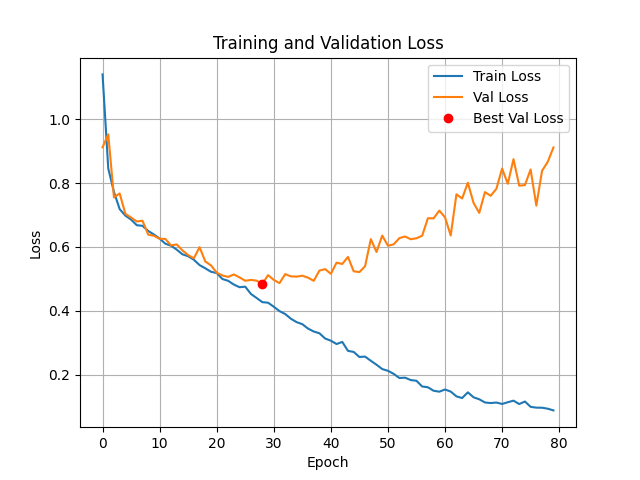

**Figura 2:** curva de aprendizado do treinamento da U-Net.

# 5. Entrega

A entrega consiste do notebook no formato **.ipynb** e de um relatório, submetida através do Google Classroom. Modificações nos arquivos do código base são permitidas, desde que o nome e a interface dos scripts “main” não sejam alterados. A princípio, não há limitação de número de páginas para o relatório, mas pede-se que seja sucinto. O relatório deve conter:
- Figuras que comprovem o funcionamento do seu código.
- Demais solicitações feitas ao longo do roteiro.

Por limitações do Google Classroom (e por motivo de facilitar a automatização da correção), entregue seu laboratório com todos os arquivos num único arquivo **.zip** (**não** utilize outras tecnologias de compactação de arquivos) com o seguinte padrão de nome: **“<login_email_google_education>_labX.zip”**. Por exemplo, no meu caso, meu login Google Education é **marcos.maximo**, logo eu entregaria o lab 4 como **“marcos.maximo_lab4.zip”**. **Não** crie subpastas para os arquivos da sua entrega, **deixe todos os arquivos na “raiz” do .zip**.